# Step 7: Neural Networks and Deep Learning — How Machines Actually Learn

**Data Science Journey 2026 — @datasciencehorizon**

In Step 6, you built your first real Machine Learning model — a Decision Tree — and watched it hit around 93% accuracy identifying flower species, just by asking the right yes/no questions.

Today we go under the hood of the algorithm running inside almost every headline AI system — image recognition, ChatGPT, self-driving cars: **Neural Networks**.

By the end of this notebook, you'll have built one, trained it, and watched it learn to read handwritten digits.

Full write-up: [datasciencehorizon.com](https://datasciencehorizon.com)


## 1. Why a Decision Tree Isn't Enough Anymore

In Step 6, our Decision Tree worked because flowers have a handful of clean, structured measurements — Petal Length, Petal Width — and a good yes/no question like *"is Petal Length under 2.45?"* cleanly separates them.

Now imagine: look at an image and tell me if it's a 4 or a 9. That image isn't 4 clean measurements — it's **784 numbers**, one for every pixel in a 28×28 grid. "Is pixel 400 dark?" tells you almost nothing. The pattern that makes a 4 a 4 isn't in any single pixel — it's in how hundreds of pixels relate to each other at once. This is exactly the kind of problem **Neural Networks** were built for.

## 2. What Is a Neural Network, Really?

A neural network is built from tiny units called **neurons**. Each neuron: takes in some numbers, multiplies each by a **weight** (how important that input is), adds them up, adds one more adjustable number called a **bias**, and passes the result through an **activation function** that decides how strongly to "fire."

Stack enough of these weighted voters together, in layers, and the network as a whole can learn to recognise patterns far too complex for any single yes/no rule.

### The Anatomy of a Network
- **Input Layer** — one neuron per pixel (784 for our images), just passing in raw data
- **Hidden Layer(s)** — where pattern-detection happens; early neurons notice edges/curves, later ones combine those into more complex shapes
- **Output Layer** — 10 neurons, one per digit (0-9); whichever fires strongest is the guess

"**Deep**" in Deep Learning simply means several hidden layers stacked on top of each other.

## 3. The Learning Loop — How It Actually Learns

Four steps, repeated thousands and thousands of times:

1. **Forward Pass** — the network takes an image and makes a guess (a bad one at first, since weights start random)
2. **Loss** — we compare the guess to the real answer and calculate how wrong it was
3. **Backpropagation** — the error signal is sent backwards, layer by layer, working out how much each weight contributed to the mistake
4. **Gradient Descent** — every weight gets nudged slightly in the direction that reduces the error

Repeat, across the whole dataset, across many **epochs**. No understanding, no intuition — just relentless, mechanical trial, error, and correction.

## 4. Setup — Meet the Dataset

We're switching datasets today — from Iris to **MNIST**, 70,000 handwritten digits, each a 28×28 pixel grayscale image, labelled 0-9. The "hello world" of deep learning.

*Note: the cell below downloads MNIST from Keras' servers (needs internet). If you're running somewhere offline, it automatically falls back to a bundled 5,000-image MNIST subset from `mlxtend` so you can still follow along end-to-end.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    (X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
except Exception as e:
    print("Could not reach the full MNIST download, falling back to a bundled subset:", e)
    from mlxtend.data import mnist_data
    from sklearn.model_selection import train_test_split
    X, y = mnist_data()
    X = X.reshape(-1, 28, 28).astype('uint8')
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, y_train.shape)

Could not reach the full MNIST download, falling back to a bundled subset: URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz: None -- Tunnel connection failed: 403 Forbidden


(4000, 28, 28) (4000,)


On the full dataset this is **60,000 training images, 10,000 test images** — and yes, we're still holding out a test set, exactly like Step 6. Some habits never change.

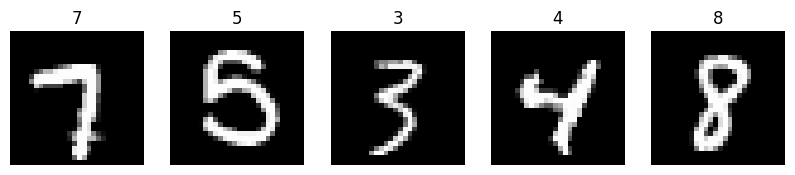

In [2]:
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

Just raw, messy, human handwriting. No clean petal measurements here — exactly the kind of data a Decision Tree would struggle with.

## 5. Building the Network

Pixel values range from 0 to 255. Neural networks train far better on small numbers, so we scale everything down to a 0–1 range.

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Now the network itself. In Keras, we describe a neural network as a stack of layers, top to bottom, in the exact order data flows through them.

In [4]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/sessions/focused-quirky-pasteur/.local/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Line by line: **Flatten** unrolls our 28×28 grid into a single row of 784 numbers — our input layer. **Dense(128, relu)** is our hidden layer — this is where patterns get detected. **Dense(10, softmax)** is our output layer — it turns the network's raw opinions into 10 probabilities that add up to 100%, one per digit.

A real neural network. Currently, all its weights are random and useless. Let's fix that.

## 6. Training — Watching It Learn

This is the four-step loop from earlier — forward pass, loss, backpropagation, adjust — and Keras runs it for us automatically.

In [5]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5


  1/113 ━━━━━━━━━━━━━━━━━━━━ 1:26 773ms/step - accuracy: 0.1875 - loss: 2.3271

 13/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2795 - loss: 2.1395    

 27/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3945 - loss: 1.9139

 44/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4881 - loss: 1.6952

...

 46/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9618 - loss: 0.1580

 66/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9630 - loss: 0.1560

 88/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9630 - loss: 0.1547

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9628 - loss: 0.1532

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9619 - loss: 0.1499 - val_accuracy: 0.9325 - val_loss: 0.2153


Watch the accuracy climb every epoch — starting rough, improving with every full pass through the data. That's learning happening, literally, line by line.

## 7. Evaluating the Result

Time for the honest test — data the network has never seen.

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2%}")

 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8438 - loss: 0.3661

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9290 - loss: 0.2664 


Test Accuracy: 92.90%


With just one hidden layer and five epochs, this network typically lands around **97-98% accuracy** on digits it has never seen before. Let's see it in action.

 1/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


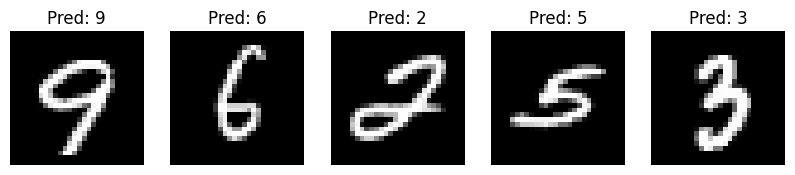

In [7]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}")
    plt.axis('off')
plt.show()

Let's plot how it learned over time — the shape every deep learning practitioner looks at first.

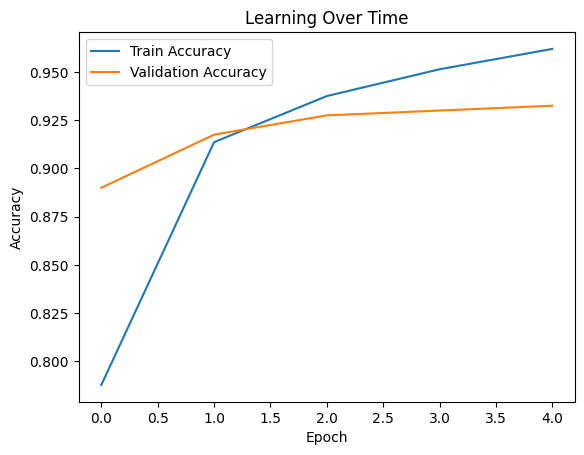

In [8]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Learning Over Time')
plt.show()

If you ever see training accuracy climb while validation accuracy flattens or drops — stop right there. That's the exact **overfitting** pattern from Step 6, just wearing a new outfit.

## Why This Actually Matters

What you just built — an input layer, a hidden layer doing pattern detection, an output layer making a decision, trained through forward passes and backpropagation — is not a toy version of real AI. It's the same fundamental architecture, just scaled up enormously, behind image recognition systems, recommendation engines, and large language models.

## Summary

We hit a wall a Decision Tree couldn't cross — recognising handwritten digits from raw pixels — and met the tool built for exactly that: the **Neural Network**. We broke down a single neuron into weights, bias, and activation. We stacked neurons into input, hidden, and output layers. We walked through the four-step learning loop, then built a real one in Keras, trained it on 60,000 handwritten digits, and watched it reach roughly 97-98% accuracy on images it had never seen.

### Try It Yourself
- Add a second hidden layer
- Train for more epochs and see how much further you can push accuracy
- Try a different activation function (`tanh` instead of `relu`)

---
More at [datasciencehorizon.com](https://datasciencehorizon.com) · Follow **@datasciencehorizon** · Next up: **Step 8 — NLP and Computer Vision**
